In [14]:
import numpy as np
import xarray as xr
import pandas as pd
import datetime

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

import os
import math

import dask
from dask.distributed import Client
from dask import delayed

import locale 

In [15]:
locale.setlocale(locale.LC_TIME, "es_ES");

# Inicio

In [45]:
# Daily data
ds = xr.open_dataset('./grid_1__9010_levels_500.nc')
ds

<xarray.Dataset> Size: 211MB
Dimensions:    (latitude: 181, longitude: 361, depth: 100, levels: 2, level: 2)
Coordinates:
  * latitude   (latitude) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
  * depth      (depth) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * levels     (levels) int64 16B 4000 4500
    times      (latitude, longitude, depth) datetime64[ns] 52MB ...
Dimensions without coordinates: level
Data variables:
    profiles   (latitude, longitude, depth) float64 52MB ...
    t_means    (latitude, longitude, depth, levels) float64 105MB ...
    n          (latitude, longitude) float64 523kB ...
    tendency   (latitude, longitude, level) float64 1MB ...

## Tendencia por coordenadas

<>:48: SyntaxWarning: invalid escape sequence '\c'
<>:48: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Mario\AppData\Local\Temp\ipykernel_41824\144028873.py:48: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Temperatura [($^\circ$C)]')


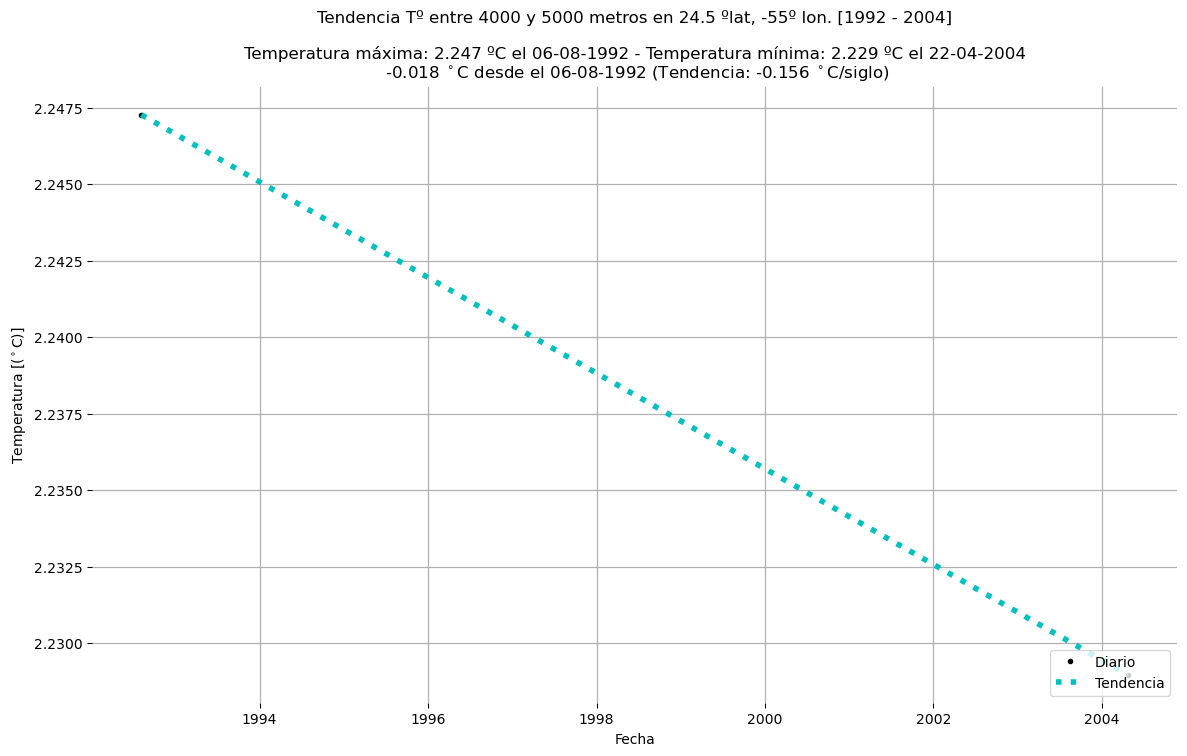

In [63]:
# Seleccionar un punto específico en latitude and longitude 
latitude = 24.5  # Define latitude
longitude = -55  # Define longitude
levels = 4500  # Define levels

t_means_1d = ds.t_means.sel(latitude=latitude, longitude=longitude, levels=levels, method="nearest")
times_1d     = ds.times.sel(latitude=latitude, longitude=longitude, method="nearest") 
nans = np.where(np.isnan(times_1d) == True)
last_ind = np.min(nans) - 1


tmax = t_means_1d.isel(t_means_1d.argmax(...))
tmin = t_means_1d.isel(t_means_1d.argmin(...))

d_tmax = times_1d.isel(t_means_1d.argmax(...))
d_tmin = times_1d.isel(t_means_1d.argmin(...))

# Linear Fit
ind = np.isfinite(t_means_1d)
times_numeric = times_1d[ind].astype('datetime64[ns]').astype(np.int64)  # Convert times to numeric format
z = np.polyfit(times_numeric-times_numeric[0], t_means_1d[ind], 1)  # Perform linear fit
linearf = z[0] * (times_1d.astype('datetime64[ns]').astype(np.int64) - times_numeric[0])+ z[-1]  # Calculate linear fit line
Dslope = z[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century


TituloFigura = f"Tendencia Tº entre 4000 y 5000 metros en {latitude} ºlat, {longitude}º lon."
tPeriodo = f" [{times_1d[0].dt.strftime('%Y').values} - {times_1d[last_ind].dt.strftime('%Y').values}]\n"
tTActual = f"{times_1d[last_ind].dt.strftime('%d-%m-%Y').values} %2.3f $^\\circ$C" % (t_means_1d[-1].values)
tTMaxima = f"Temperatura máxima: %2.3f ºC" % (t_means_1d.max().values) + f" el {times_1d[t_means_1d.argmax()].dt.strftime('%d-%m-%Y').values}"
tTMinima = f"Temperatura mínima: %2.3f ºC" % (t_means_1d.min().values) + f" el {times_1d[t_means_1d.argmin()].dt.strftime('%d-%m-%Y').values}"
tTendencia = (
    f"\n %2.3f $^\\circ$C" % (t_means_1d[last_ind] - t_means_1d[0])
    + f" desde el {times_1d[0].dt.strftime('%d-%m-%Y').values} "
    + f"(Tendencia: %2.3f" % (Dslope) + " $^\\circ$C/siglo)"
)

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.plot(times_1d, t_means_1d, 'k.', linewidth=4, label='Diario')
ax.plot(times_1d, linearf, 'c:', linewidth=4, label='Tendencia')

ax.set_title(TituloFigura + tPeriodo + '\n' + tTMaxima + ' - ' + tTMinima + tTendencia);
ax.legend(loc=4)



ax.grid(linestyle='-', linewidth=0.9)
ax.set_ylabel('Temperatura [($^\circ$C)]')
ax.set_xlabel('Fecha')
ax.set_frame_on(False)
# plt.savefig()

In [57]:
z = np.polyfit(np.array([1000000]), t_means_1d[ind], 1)  # Perform linear fit
z

C:\Users\Mario\AppData\Local\Temp\ipykernel_41824\1380221164.py:1: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(np.array([1000000]), t_means_1d[ind], 1)  # Perform linear fit


array([1.22026741e-06, 1.22026741e+00])

In [ ]:
# Calcular la diferencia de tiempo entre la primera y la última medida válida
valid_times = times_1d[np.isfinite(times_1d)]
if len(valid_times) > 1:
    timespan = (valid_times.values[-1] - valid_times.values[0]).astype('timedelta64[D]').astype(int)
    if timespan >= 912.5:
        print(f"Hay al menos 2.5 años entre la primera y última medida: {timespan} días.")
    else:
        print(f"No hay al menos 2.5 años entre la primera y última medida: {timespan} días.")
else:
    print("No hay suficientes medidas válidas para calcular el intervalo de tiempo.")

Hay al menos 2.5 años entre la primera y última medida: 4367 días.


In [65]:
ds = xr.open_dataset('./grid_1__9010_levels_500.nc')
ds

<xarray.Dataset> Size: 211MB
Dimensions:    (latitude: 181, longitude: 361, depth: 100, levels: 2, level: 2)
Coordinates:
  * latitude   (latitude) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
  * depth      (depth) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * levels     (levels) int64 16B 4000 4500
    times      (latitude, longitude, depth) datetime64[ns] 52MB ...
Dimensions without coordinates: level
Data variables:
    profiles   (latitude, longitude, depth) float64 52MB ...
    t_means    (latitude, longitude, depth, levels) float64 105MB ...
    n          (latitude, longitude) float64 523kB ...
    tendency   (latitude, longitude, level) float64 1MB ...

In [66]:
# Initialize an empty array to store the tendency values for each level
tendency = np.full((len(ds.latitude), len(ds.longitude), len(ds.t_means.levels)), np.nan)
levels = 4000
# Iterate over all latitude, longitude, and level points
for i, lat in enumerate(ds.latitude.values):
    for j, lon in enumerate(ds.longitude.values):
        #for k, levels in enumerate(ds.t_means.levels.values):  # Iterate over levels
            # Select the data for the current latitude, longitude, and level
            t_means_1d = ds.t_means.sel(latitude=lat, longitude=lon, levels=levels, method="nearest")
            times_1d = ds.times.sel(latitude=lat, longitude=lon, method="nearest")
            
            # Check if there are enough valid data points to calculate the tendency
            ind = np.isfinite(t_means_1d) & np.isfinite(times_1d)  # Ensure both arrays are valid
            if ind.sum() > 2:  # Ensure there are at least 3 valid points
                # Check if the timespan is at least 2.5 years
                valid_times = times_1d[ind]
                if len(valid_times) > 1:  # Ensure there are at least two valid time points
                    timespan = (valid_times[-1] - valid_times[0]).astype('timedelta64[D]').astype(int)
                    if timespan >= 912.5:  # 2.5 years in days
                        times_numeric = valid_times.astype('datetime64[ns]').astype(np.int64)
                        z = np.polyfit(times_numeric, t_means_1d[ind], 1)
                        Dslope = z[0] / 1.e-9 * 24 * 3600 * 365 * 100  # Convert slope to °C per century
                        tendency[i, j, k] = Dslope

# Add the tendency array as a new variable to the dataset
ds["tendency"] = (("latitude", "longitude", "level"), tendency)

C:\Users\Mario\AppData\Local\Temp\ipykernel_41824\298729809.py:18: UserWarning: Converting non-nanosecond precision timedelta values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  timespan = (valid_times[-1] - valid_times[0]).astype('timedelta64[D]').astype(int)
C:\Users\Mario\AppData\Local\Temp\ipykernel_41824\298729809.py:18: UserWarning: Converting non-nanosecond precision timedelta values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 val

In [72]:
for k, levels in enumerate(ds.t_means.levels.values):  # Iterate over levels
    print(f"Level {levels} : {ds.tendency[:,:,k].sum().values}")
k

Level 4000 : 0.0
Level 4500 : 164.70817844646166


1

In [ ]:
# Save the updated dataset to a new NetCDF file
ds.to_netcdf("grid_05__9010_levels_500.nc")

In [68]:
#ds = xr.open_dataset('./grid_1_45k.nc')
ds.tendency.shape

(181, 361, 2)

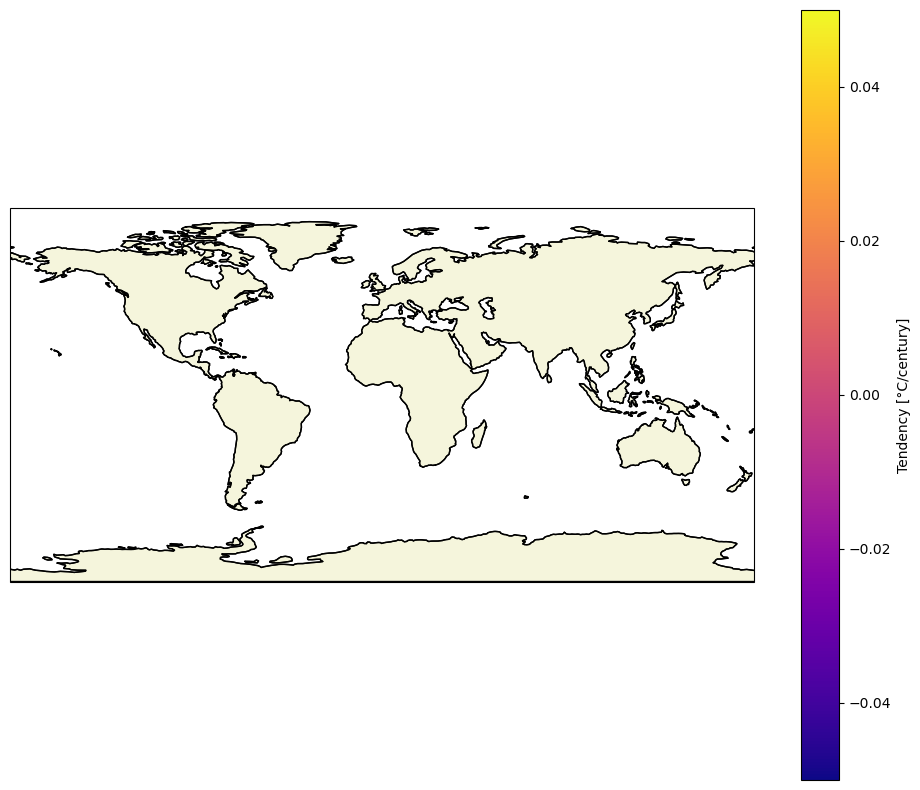

In [67]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature


fig = plt.figure(figsize=(12,10))

projection = ccrs.PlateCarree(central_longitude=0.0)
ax = plt.axes(projection=projection)
land = cartopy.feature.NaturalEarthFeature('physical',
                'land', edgecolor='k', scale = '110m' ,
                facecolor=cfeature.COLORS['land'])

ax.add_feature(land, facecolor='beige')
ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey')
ax.add_feature(cfeature.COASTLINE, zorder=2, edgecolor='black')
ds.tendency[:,:,0].plot(ax=ax, cmap='plasma', cbar_kwargs={'label': 'Tendency [°C/century]'})


In [69]:
# Find the indices of the maximum tendency
max_tendency_index = np.unravel_index(np.nanargmax(ds.tendency.values), ds.tendency.shape)

# Extract the latitude and longitude corresponding to the maximum tendency
max_latitude = ds.latitude[max_tendency_index[0]].values
max_longitude = ds.longitude[max_tendency_index[1]].values

print(f"Highest tendency: {ds.tendency.values[max_tendency_index]} °C/century")
print(f"Latitude: {max_latitude}, Longitude: {max_longitude}")

Highest tendency: 194.48312328597888 °C/century
Latitude: -22.0, Longitude: -170.0


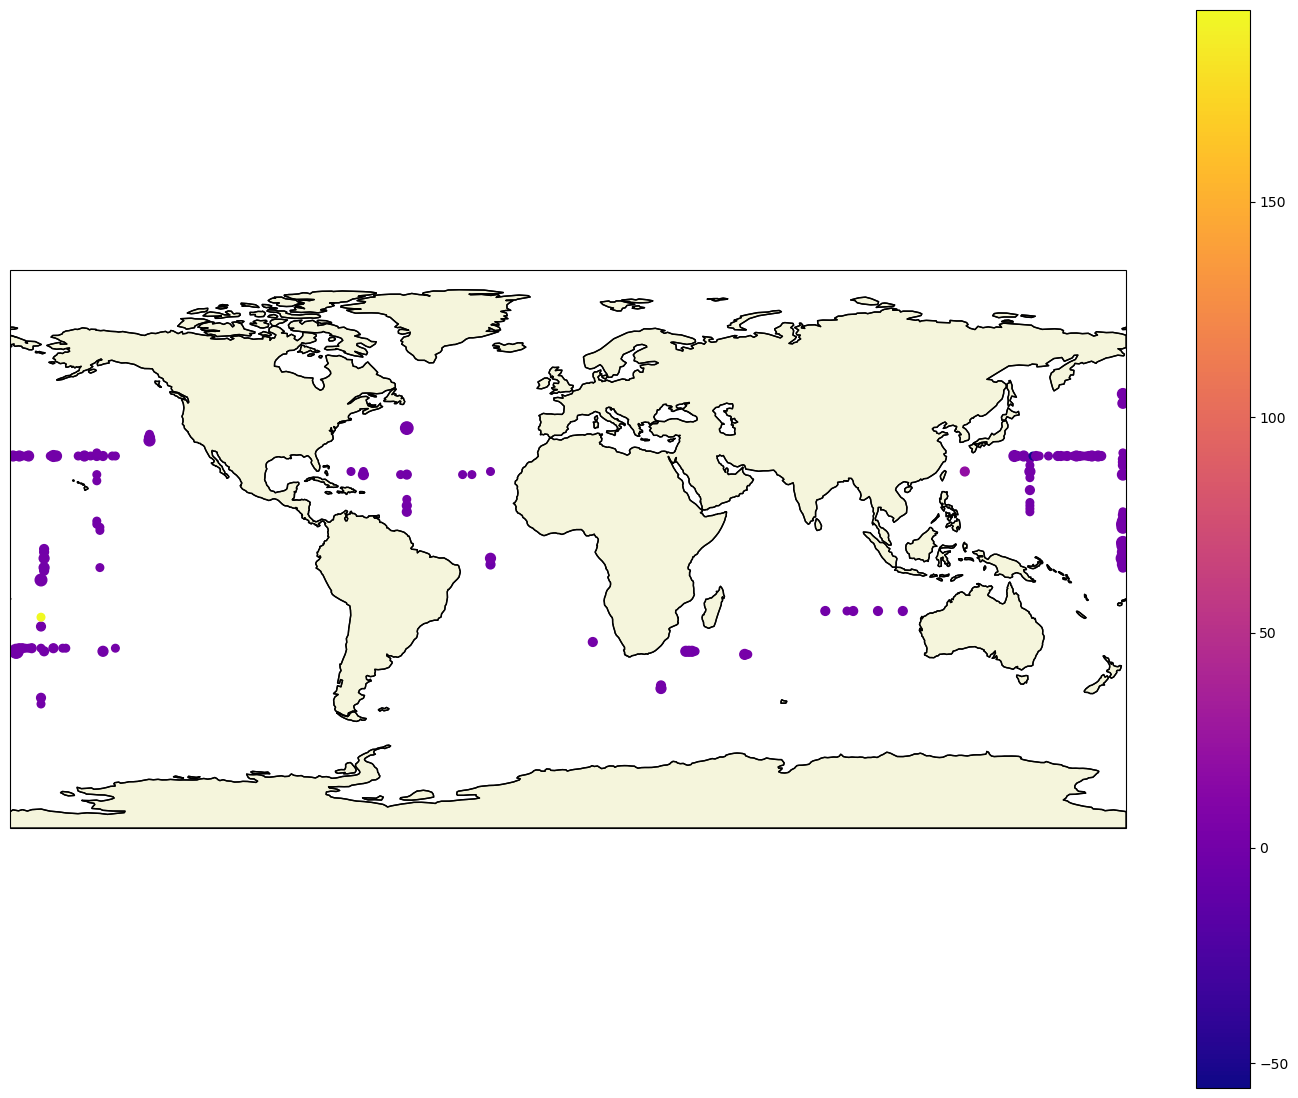

In [73]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature


fig = plt.figure(figsize=(18,14))

projection = ccrs.PlateCarree(central_longitude=0.0)
ax = plt.axes(projection=projection)
land = cartopy.feature.NaturalEarthFeature('physical',
                'land', edgecolor='k', scale = '110m' ,
                facecolor=cfeature.COLORS['land'])

ax.add_feature(land, facecolor='beige')
ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey')
ax.add_feature(cfeature.COASTLINE, zorder=2, edgecolor='black')

X, Y = np.meshgrid(ds.longitude.values,ds.latitude.values)
z=ds.tendency[:,:,1].values

#ds.tendency.plot(ax=ax, cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'label': 'Tendency [°C/century]'})
hsc=ax.scatter(X,Y,c=z, cmap='plasma', s=10*ds.n.values, )
fig.colorbar(hsc)


Mean tendency: 1.286782644112982 °C/century


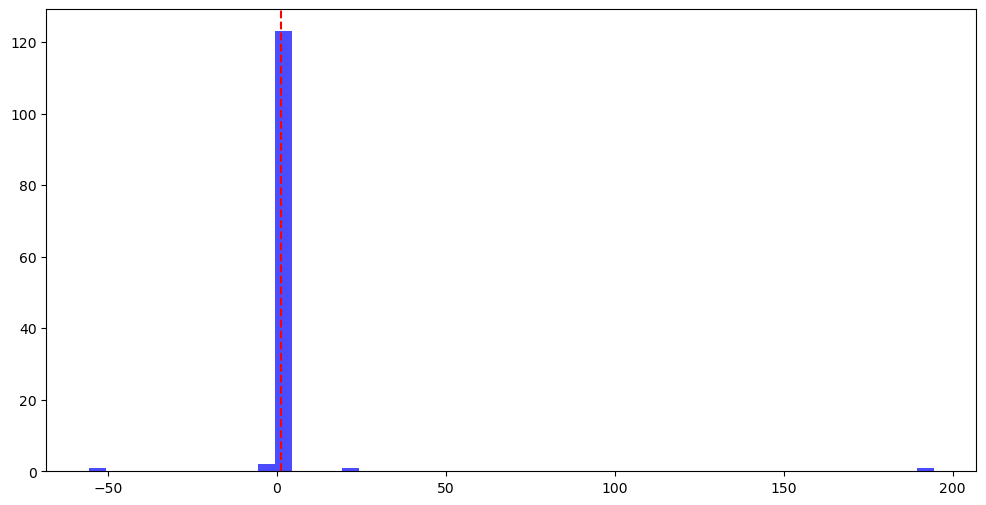

In [74]:
plt.figure(figsize=(12, 6))
plt.hist(ds.tendency[:, :, 1].values.flatten(), bins=50, color='blue', alpha=0.7)
plt.axvline(x= np.nanmean(ds.tendency.values), color='red', linestyle='--', label='Mean tendency')

print(f"Mean tendency: {np.nanmean(ds.tendency.values)} °C/century")
#plt.ylim(0, 100)

In [ ]:
def find_high_tendencies(ds, threshold= 10):
    
    """
    Encuentra todas las tendencias mayores al umbral especificado y devuelve sus coordenadas.

    Parameters:
        ds (xarray.Dataset): Dataset que contiene la variable 'tendency'.
        threshold (float): Umbral de tendencia en grados por siglo.

    Returns:
        list: Lista de tuplas con las coordenadas (latitud, longitud) de las tendencias mayores al umbral.
    """
    # Encuentra los índices donde la tendencia es mayor al umbral
    indices = np.where(ds.tendency.values > threshold)
    
    # Extrae las coordenadas correspondientes
    latitudes = ds.latitude.values[indices[0]]
    longitudes = ds.longitude.values[indices[1]]
    
    # Combina las coordenadas en una lista de tuplas
    coordinates = list(zip(latitudes, longitudes))
    
    return coordinates



# Uso de la función
high_tendency_coords = find_high_tendencies(ds, threshold=1)
print(f"Coordenadas con tendencias mayores a 10 °C/siglo: {high_tendency_coords}")


Coordenadas con tendencias mayores a 10 °C/siglo: [(-44.0, 30.0), (-43.0, 30.0), (-34.0, 57.0), (-34.0, 58.0), (16.0, -52.0)]
